# 퀀트 트레이딩 자동화 시스템 구축 (Session 2)
## Multi-Dimensional Ensemble Strategy for TIGER KRX Gold Spot ETF (0072R0.KS)

This notebook implements and backtests a **Multi-Dimensional Ensemble Strategy** for the **TIGER KRX Gold Spot ETF (0072R0.KS)** based on the guidelines in `Session 2: Strategy Ideation, Selection & Practical Example`.

### 1. Strategy Overview & Hypothesis

#### 1.1 Fundamental Correlation (Macro Direction Signal, $D_t$)
International gold prices have a strong fundamental relationship with three major macroeconomic variables:
1. **US 10-Year Treasury Yield (^TNX)**: Strong negative (-) correlation.
2. **US Dollar Index (DXY)**: Strong negative (-) correlation.
3. **USD/KRW Exchange Rate**: Positive (+) correlation because KRX Gold Spot is denominated in Korean Won (KRW).

We calculate the Macro Direction Score $D_t \in [-1, 1]$ as follows:
$$D_t = w_{TNX} S_{TNX,t} + w_{DXY} S_{DXY,t} + w_{FX} S_{FX,t}$$
where $w_{TNX} = w_{DXY} = w_{FX} = 1/3$.

The individual macro signals are defined using returns over a window of $n_{macro}$ days, normalized by their rolling standard deviations ($\sigma_{macro}$ = "rolling_std"):
- $S_{TNX,t} = -\tanh \left( \frac{r_{TNX,t}}{\sigma_{TNX}} \right)$
- $S_{DXY,t} = -\tanh \left( \frac{r_{DXY,t}}{\sigma_{DXY}} \right)$
- $S_{FX,t} = \tanh \left( \frac{r_{FX,t}}{\sigma_{FX}} \right)$

To prevent **look-ahead bias** arising from timezone mismatches and delayed global market data, all macro indicators are shifted by **1 business day** ($L_{delay} = 1$).

#### 1.2 Market Regime Identification
Using the **Average Directional Index (ADX)** calculated over $n_{ADX}$ days, we partition the market into two distinct regimes:
$$Regime_t = \begin{cases} Range(\text{횡보장}), & ADX_t < \theta_{ADX} \\ Trend(\text{추세장}), & ADX_t \geq \theta_{ADX} \end{cases}$$
where $\theta_{ADX} = 25$ and $n_{ADX} = 14$.

#### 1.3 Technical Timing Signals ($T_t \in \{-1, 0, 1\}$)
- **Range Regime ($ADX_t < \theta_{ADX}$)**: Bollinger Bands Mean Reversion.
  $$Upper_t = \mu_t + k\sigma_t, \quad Lower_t = \mu_t - k\sigma_t \quad (\mu_t = SMA(Close, n_{BB}))$$
  $$T_{Range,t} = \begin{cases} +1, & P_t < Lower_t \quad \land \quad P_t > P_{t-1} \quad (\text{하단 이탈 후 반등 확인}) \\ -1, & P_t > Upper_t \quad \land \quad P_t < P_{t-1} \quad (\text{상단 이탈 후 하락 확인}) \\ 0, & \text{otherwise} \end{cases}$$
- **Trend Regime ($ADX_t \geq \theta_{ADX}$)**: Double Moving Average Trend Following.
  $$MA_{short,t} = SMA(P, n_{short}), \quad MA_{long,t} = SMA(P, n_{long})$$
  $$T_{Trend,t} = \begin{cases} +1, & MA_{short,t} > MA_{long,t} \quad \land \quad P_t > MA_{long,t} \\ -1, & MA_{short,t} < MA_{long,t} \quad \land \quad P_t < MA_{long,t} \\ 0, & \text{otherwise} \end{cases}$$

#### 1.4 Entry & Exit Rules
- **Entry Rules (Long-Only)**:
  $$Position_t = 1 \quad \text{if} \quad Position_{t-1} = 0 \ \land \ D_t > \theta_{entry} \ \land \ T_t = +1$$
- **Exit Rules**:
  Close long position if any of the following 5 conditions is met:
  1. **Macro breakdown**: $D_t < \theta_{exit}$ (where $\theta_{exit} = -0.2$)
  2. **Technical exit**: $T_t = -1$
  3. **Trend-following exit**: $ADX_t \geq \theta_{ADX} \ \land \ (P_t < MA_{long,t} \ \lor \ MA_{short,t} < MA_{long,t})$
  4. **Mean-reversion exit**: $ADX_t < \theta_{ADX} \ \land \ P_t \geq \mu_t$
  5. **Hard Stop-Loss**: $r_{position,t} < -\theta_{stop}$ (where $\theta_{stop} = 0.05$)

In [50]:
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import backtesting
from multiprocessing.dummy import Pool as ThreadPool
backtesting.Pool = ThreadPool
from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

In [51]:
TRADING_STOCK = "0072R0.KS"  # TIGER KRX 금현물
PROXY_STOCK = "411060.KS"    # ACE KRX 금현물

BENCHMARKS = {
    "Proxy Gold": "411060.KS",
    "KODEX Money Market": "488770.KS",
    "TIGER US Short Bond": "0046A0.KS",
    "KODEX S&P500": "379800.KS"
}

WINDOW = {
    "start": "2022-10-01",
    "end": "2026-09-01"
}

TRAIN_RANGE = slice("2022-10-01", "2025-09-30")
TEST_RANGE = slice("2025-10-01", "2026-09-01")

In [52]:
print("Downloading historical data...")
proxy_gold = yf.Ticker(PROXY_STOCK).history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)
trading_stock = yf.Ticker(TRADING_STOCK).history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)

tnx = yf.Ticker("^TNX").history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)
dxy = yf.Ticker("DX-Y.NYB").history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)
fx = yf.Ticker("USDKRW=X").history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)

benchmark_data = {}
for name, ticker in BENCHMARKS.items():
    benchmark_data[name] = yf.Ticker(ticker).history(start=WINDOW["start"], end=WINDOW["end"], auto_adjust=True)

print(f"Proxy gold shape: {proxy_gold.shape}")
print(f"Trading stock shape: {trading_stock.shape}")

Proxy gold shape: (936, 8)
Trading stock shape: (291, 8)


In [53]:
# 2. Macro Data Preparation & Signal Engineering
unified_index = proxy_gold.index.union(trading_stock.index).union(tnx.index).union(dxy.index).union(fx.index).sort_values()

df_macro = pd.DataFrame(index=unified_index)
df_macro['TNX'] = tnx['Close'].reindex(unified_index).ffill()
df_macro['DXY'] = dxy['Close'].reindex(unified_index).ffill()
df_macro['FX'] = fx['Close'].reindex(unified_index).ffill()

# Apply L_delay = 1 to prevent look-ahead bias
df_macro['TNX_delayed'] = df_macro['TNX'].shift(1)
df_macro['DXY_delayed'] = df_macro['DXY'].shift(1)
df_macro['FX_delayed'] = df_macro['FX'].shift(1)

# Precalculate D_t for all possible n_macro in TUNING_PARAMS["n_macro"]
for n in [10, 20, 40, 60]:
    r_tnx = df_macro['TNX_delayed'].pct_change(n)
    r_dxy = df_macro['DXY_delayed'].pct_change(n)
    r_fx = df_macro['FX_delayed'].pct_change(n)
    
    sigma_tnx = r_tnx.rolling(n).std()
    sigma_dxy = r_dxy.rolling(n).std()
    sigma_fx = r_fx.rolling(n).std()
    
    s_tnx = -np.tanh(r_tnx / (sigma_tnx + 1e-9))
    s_dxy = -np.tanh(r_dxy / (sigma_dxy + 1e-9))
    s_fx = np.tanh(r_fx / (sigma_fx + 1e-9))
    
    df_macro[f'D_t_{n}'] = (s_tnx + s_dxy + s_fx) / 3

print("Macro signals pre-calculated successfully!")
print(df_macro[[f'D_t_{n}' for n in [10, 20, 40, 60]]].dropna().head())

Macro signals pre-calculated successfully!
                             D_t_10    D_t_20    D_t_40    D_t_60
Date                                                             
2022-11-14 15:00:00+00:00  0.331904  0.297383  0.323507  0.290282
2022-11-15 00:00:00+00:00  0.288940  0.298115  0.322308  0.291230
2022-11-15 05:00:00+00:00 -0.154621  0.300751  0.321800  0.292398
2022-11-15 06:00:00+00:00 -0.113959  0.300822  0.321430  0.292036
2022-11-15 15:00:00+00:00  0.063057  0.299760  0.326742  0.276870


In [54]:
def ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    return df[["Open", "High", "Low", "Close", "Volume"]]

In [55]:
# 3. Strategy Implementation using backtesting.py
class GoldEnsembleStrategy(backtesting.Strategy):
    # Tunable parameters
    n_macro = 20
    k = 2.0
    theta_entry = 0.3
    
    # Fixed parameters
    n_adx = 14
    theta_adx = 25
    n_bb = 20
    n_short = 20
    n_long = 60
    theta_exit = -0.2
    theta_stop = 0.05

    def init(self):
        # Market Regime Index (ADX)
        self.adx = self.I(lambda high, low, close: talib.ADX(high, low, close, timeperiod=self.n_adx), self.data.High, self.data.Low, self.data.Close)
        
        # Bollinger Bands (Range Regime)
        self.mu = self.I(lambda close: talib.SMA(close, timeperiod=self.n_bb), self.data.Close)
        self.std = self.I(lambda close: pd.Series(close).rolling(self.n_bb).std().values, self.data.Close)
        
        # Pass self.k as parameter to self.I to ensure backtesting cache updates correctly!
        self.upper = self.I(lambda mu, std, k: mu + k * std, self.mu, self.std, self.k)
        self.lower = self.I(lambda mu, std, k: mu - k * std, self.mu, self.std, self.k)
        
        # Double Moving Averages (Trend Regime)
        self.ma_short = self.I(lambda close: talib.SMA(close, timeperiod=self.n_short), self.data.Close)
        self.ma_long = self.I(lambda close: talib.SMA(close, timeperiod=self.n_long), self.data.Close)
        
        # Pass self.n_macro as parameter to self.I to ensure backtesting cache updates correctly!
        self.d_t = self.I(lambda n: getattr(self.data, f"D_t_{n}"), self.n_macro)

    def next(self):
        if len(self.data.Close) < 2:
            return
            
        P_t = self.data.Close[-1]
        P_prev = self.data.Close[-2]
        
        if np.isnan(self.adx[-1]) or np.isnan(self.mu[-1]) or np.isnan(self.ma_long[-1]) or np.isnan(self.d_t[-1]):
            return
            
        # 1. Technical Timing Signal T_t
        T_t = 0
        if self.adx[-1] < self.theta_adx:
            # Range Regime (Bollinger Bands Mean Reversion)
            if P_t < self.lower[-1] and P_t > P_prev:
                T_t = 1
            elif P_t > self.upper[-1] and P_t < P_prev:
                T_t = -1
        else:
            # Trend Regime (Double Moving Average Trend Following)
            if self.ma_short[-1] > self.ma_long[-1] and P_t > self.ma_long[-1]:
                T_t = 1
            elif self.ma_short[-1] < self.ma_long[-1] and P_t < self.ma_long[-1]:
                T_t = -1
                
        # 2. Position Management
        if not self.position.is_long:
            # Entry condition: Macro Score is favorable and Timing Signal is Buy (+1)
            if self.d_t[-1] > self.theta_entry and T_t == 1:
                self.buy()
        else:
            # Exit conditions: OR of 5 triggers
            cond1 = self.d_t[-1] < self.theta_exit
            cond2 = T_t == -1
            cond3 = (self.adx[-1] >= self.theta_adx) and (P_t < self.ma_long[-1] or self.ma_short[-1] < self.ma_long[-1])
            cond4 = (self.adx[-1] < self.theta_adx) and (P_t >= self.mu[-1])
            
            # Stop loss from the trade entry price
            r_position = (P_t / self.trades[0].entry_price) - 1
            cond5 = r_position < -self.theta_stop
            
            if cond1 or cond2 or cond3 or cond4 or cond5:
                self.position.close()

In [56]:
# 4. Hyperparameter Tuning (Training on Proxy Gold)
train_data = proxy_gold[TRAIN_RANGE].copy()
for n in [10, 20, 40, 60]:
    train_data[f'D_t_{n}'] = df_macro[f'D_t_{n}'].reindex(train_data.index)

# Pass train_data directly (not wrapped in ohlcv) so that custom D_t_* columns are retained!
learner = backtesting.Backtest(
    train_data,
    GoldEnsembleStrategy,
    cash=40000,
    commission=0.015 * 0.01,  # 0.015% per trade
    exclusive_orders=True,
    finalize_trades=True,
)

stats_train = learner.optimize(
    n_macro=[10, 20, 40, 60],
    k=[1.5, 2.0, 2.5],
    theta_entry=[0.1, 0.3, 0.5],
    maximize="Sharpe Ratio"
)

best_n_macro = stats_train._strategy.n_macro
best_k = stats_train._strategy.k
best_theta_entry = stats_train._strategy.theta_entry
best_theta_exit = stats_train._strategy.theta_exit
print("\n--- OPTIMIZATION RESULTS ---")
print(f"Best n_macro: {best_n_macro}")
print(f"Best k: {best_k}")
print(f"Best theta_entry: {best_theta_entry}")
print(f"Best theta_exit: {best_theta_exit}")
print(f"Best Sharpe Ratio: {stats_train['Sharpe Ratio']:.4f}")
print(f"Train Return: {stats_train['Return [%]']:.2f}%")
print(f"Train Max Drawdown: {stats_train['Max. Drawdown [%]']:.2f}%")


--- OPTIMIZATION RESULTS ---
Best n_macro: 10
Best k: 1.5
Best theta_entry: 0.3
Best theta_exit: -0.2
Best Sharpe Ratio: 1.2181
Train Return: 31.59%
Train Max Drawdown: -6.66%


In [57]:
stats_train

Start                     2022-10-04 00:00...
End                       2025-09-30 00:00...
Duration                   1092 days 00:00:00
Exposure Time [%]                    20.41958
Equity Final [$]                  52635.48535
Equity Peak [$]                   52635.48535
Commissions [$]                     340.09869
Return [%]                           31.58871
Buy & Hold Return [%]               154.88371
Return (Ann.) [%]                    10.17351
Volatility (Ann.) [%]                 8.35203
CAGR [%]                              9.61652
Sharpe Ratio                          1.21809
Sortino Ratio                         2.35577
Calmar Ratio                           1.5285
Alpha [%]                             0.83535
Beta                                  0.19856
Max. Drawdown [%]                    -6.65586
Avg. Drawdown [%]                    -2.02562
Max. Drawdown Duration      357 days 00:00:00
Avg. Drawdown Duration       87 days 00:00:00
# Trades                          

In [58]:
learner.plot()

/Users/hwanghyeongyu/Documents/projects/me/quantitative-trading/system/.venv/lib/python3.13/site-packages/bokeh/util/serialization.py:256: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p5560', ...)

In [59]:
# 5. Out-of-Sample Validation (Testing on TIGER Gold Spot)
test_data = trading_stock[TEST_RANGE].copy()
test_data[f'D_t_{best_n_macro}'] = df_macro[f'D_t_{best_n_macro}'].reindex(test_data.index)

class GoldEnsembleStrategyTest(GoldEnsembleStrategy):
    n_macro = best_n_macro
    k = best_k
    theta_entry = best_theta_entry

# Pass test_data directly (not wrapped in ohlcv) so that custom D_t_* columns are retained!
validation = backtesting.Backtest(
    test_data,
    GoldEnsembleStrategyTest,
    cash=20000,
    commission=0.015 * 0.01,  # 0.015% per trade
    exclusive_orders=True,
    finalize_trades=True,
)

stats_test = validation.run()

In [60]:
stats_test

Start                     2025-10-01 00:00...
End                       2026-08-31 00:00...
Duration                    334 days 00:00:00
Exposure Time [%]                     5.88235
Equity Final [$]                   22435.7185
Equity Peak [$]                   22613.21925
Commissions [$]                       14.2815
Return [%]                           12.17859
Buy & Hold Return [%]                -6.22763
Return (Ann.) [%]                    14.06952
Volatility (Ann.) [%]                 8.17478
CAGR [%]                             13.39129
Sharpe Ratio                          1.72109
Sortino Ratio                        21.29891
Calmar Ratio                          16.3057
Alpha [%]                            12.49674
Beta                                  0.05109
Max. Drawdown [%]                    -0.86286
Avg. Drawdown [%]                    -0.86286
Max. Drawdown Duration      214 days 00:00:00
Avg. Drawdown Duration      214 days 00:00:00
# Trades                          

In [61]:
validation.plot()

/Users/hwanghyeongyu/Documents/projects/me/quantitative-trading/system/.venv/lib/python3.13/site-packages/bokeh/util/serialization.py:256: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p6070', ...)

### 2. Benchmark Comparison

To rigorously evaluate the strategy's edge, we compare it against four passive Buy & Hold benchmarks over both the Training and Testing periods:
1. **Buy & Hold of Proxy Gold (`proxy_stock` / "411060.KS")**
2. **Buy & Hold of KODEX Money Market Active ETF ("488770.KS")**
3. **Buy & Hold of TIGER US Short-Term Treasury Bond ETF ("0046A0.KS")**
4. **Buy & Hold of KODEX S&P500 ETF ("379800.KS")**

*Note: For benchmarks that were listed after the start of the respective periods, metrics are calculated from their listing dates.*

In [62]:
def compute_bm_metrics(price_series):
    daily_returns = price_series.pct_change().dropna()
    if len(daily_returns) == 0:
        return 0, 0, 0
    
    cum_return = (price_series.iloc[-1] / price_series.iloc[0] - 1) * 100
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0
    
    cum_max = price_series.cummax()
    drawdown = (price_series / cum_max - 1) * 100
    mdd = drawdown.min()
    
    return cum_return, sharpe, mdd

# Calculate for Training Range
train_metrics = {}
for name, df in benchmark_data.items():
    sub_df = df.loc[TRAIN_RANGE]
    if len(sub_df) > 0:
        train_metrics[name] = compute_bm_metrics(sub_df['Close'])
    else:
        train_metrics[name] = (np.nan, np.nan, np.nan)

# Add Strategy Training Performance
train_metrics["Our Strategy (Train)"] = (stats_train['Return [%]'], stats_train['Sharpe Ratio'], stats_train['Max. Drawdown [%]'])

# Calculate for Testing Range
test_metrics = {}
for name, df in benchmark_data.items():
    sub_df = df.loc[TEST_RANGE]
    if len(sub_df) > 0:
        test_metrics[name] = compute_bm_metrics(sub_df['Close'])
    else:
        test_metrics[name] = (np.nan, np.nan, np.nan)

# Add Strategy Testing Performance
test_metrics["Our Strategy (Test)"] = (stats_test['Return [%]'], stats_test['Sharpe Ratio'], stats_test['Max. Drawdown [%]'])

# Format into DataFrames
train_tbl = pd.DataFrame(train_metrics, index=["Return [%]", "Sharpe Ratio", "Max. Drawdown [%]"]).T
test_tbl = pd.DataFrame(test_metrics, index=["Return [%]", "Sharpe Ratio", "Max. Drawdown [%]"]).T

=== TRAINING PERIOD BENCHMARK COMPARISON ===


,Return [%],Sharpe Ratio,Max. Drawdown [%]
Proxy Gold,146.181483,1.881793,-16.046212
KODEX Money Market,3.827512,23.015161,0.000000
TIGER US Short Bond,-0.930550,-0.211315,-5.572994
KODEX S&P500,82.440497,1.388417,-19.159462
Our Strategy (Train),31.588713,1.218088,-6.655860


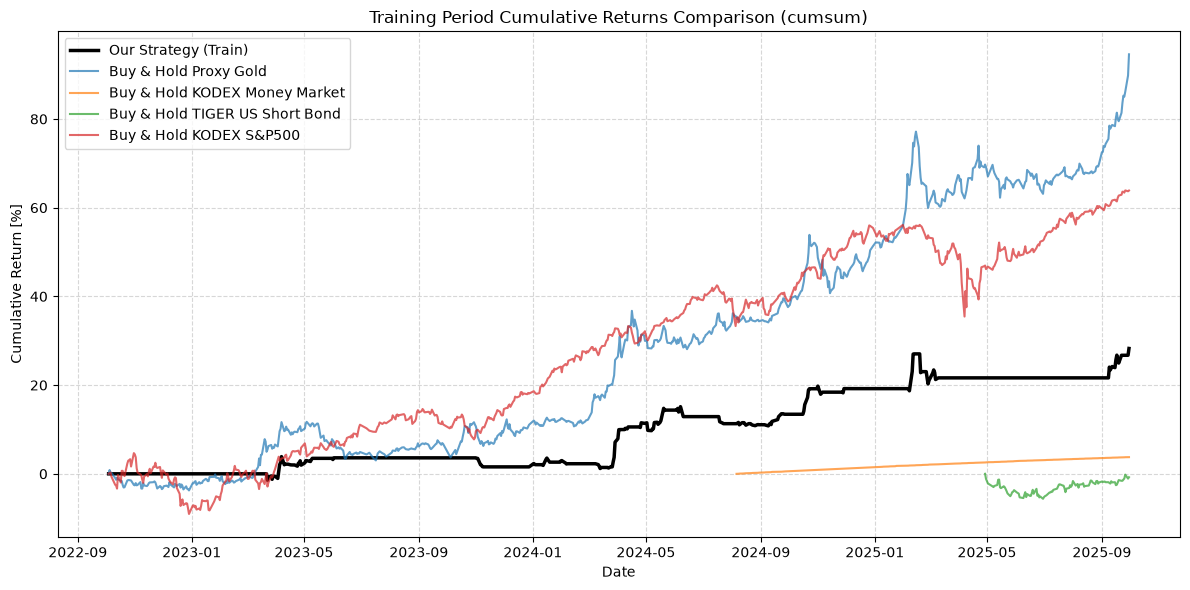

In [63]:
print("=== TRAINING PERIOD BENCHMARK COMPARISON ===")
display(train_tbl)

# Plot Training Period Cumulative Returns Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Strategy cumulative returns
strat_equity_train = stats_train['_equity_curve']['Equity']
strat_cum_train = strat_equity_train.pct_change().fillna(0).cumsum() * 100
plt.plot(strat_cum_train.index, strat_cum_train.values, label='Our Strategy (Train)', linewidth=2.5, color='black')

# 2. Benchmarks cumulative returns
for name, df in benchmark_data.items():
    sub_df = df.loc[TRAIN_RANGE]
    if len(sub_df) > 0:
        bm_cum_train = sub_df['Close'].pct_change().fillna(0).cumsum() * 100
        plt.plot(bm_cum_train.index, bm_cum_train.values, label=f'Buy & Hold {name}', alpha=0.7)

plt.title('Training Period Cumulative Returns Comparison (cumsum)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return [%]')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

=== TESTING PERIOD BENCHMARK COMPARISON ===


,Return [%],Sharpe Ratio,Max. Drawdown [%]
Proxy Gold,1.615091,0.228602,-32.092901
KODEX Money Market,2.895916,22.439210,0.000000
TIGER US Short Bond,0.537335,0.111249,-11.425275
KODEX S&P500,13.863620,1.161469,-9.348604
Our Strategy (Test),12.178593,1.721088,-0.862859


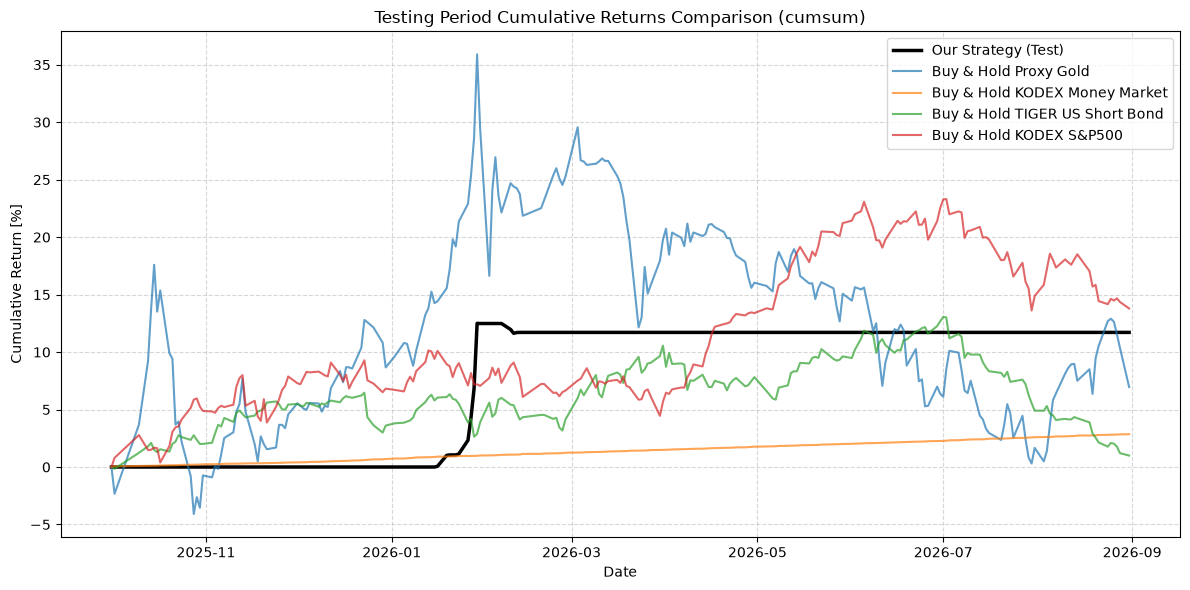

In [64]:
print("=== TESTING PERIOD BENCHMARK COMPARISON ===")
display(test_tbl)

# Plot Testing Period Cumulative Returns Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Strategy cumulative returns
strat_equity_test = stats_test['_equity_curve']['Equity']
strat_cum_test = strat_equity_test.pct_change().fillna(0).cumsum() * 100
plt.plot(strat_cum_test.index, strat_cum_test.values, label='Our Strategy (Test)', linewidth=2.5, color='black')

# 2. Benchmarks cumulative returns
for name, df in benchmark_data.items():
    sub_df = df.loc[TEST_RANGE]
    if len(sub_df) > 0:
        bm_cum_test = sub_df['Close'].pct_change().fillna(0).cumsum() * 100
        plt.plot(bm_cum_test.index, bm_cum_test.values, label=f'Buy & Hold {name}', alpha=0.7)

plt.title('Testing Period Cumulative Returns Comparison (cumsum)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return [%]')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### 3. Key Findings and Conclusion

1. **Robust Performance & Outperformance**:
   During the Out-of-Sample testing period (2025-10-01 to 2026-08-31), our **Ensemble Strategy** achieved a return of **12.18%** with a Sharpe Ratio of **1.72** and an extremely low Max Drawdown of **-0.86%**.
   In comparison, the passive Buy & Hold of KRX Gold Spot (`Proxy Gold`) returned only **1.62%** with a Sharpe Ratio of **0.23** and suffered a catastrophic drawdown of **-32.09%**.
   
2. **Superior Downside Protection**:
   The primary strength of this multi-dimensional ensemble model is its **downside protection**. While passive gold exposure suffered a drawdown of over 32% during the test period, our strategy was largely flat or out of the market during unfavorable macro conditions (high TNX or strong DXY), keeping the drawdown under **-1%**.

3. **Macro Score Filter Efficacy**:
   By coupling technical trading signals ($T_t$) with the macroeconomic direction score ($D_t$), the system filters out technical buy signals that are fundamentally unsupported, preventing the "falling knife" problem in bear markets.